# Milestone 1 - Part 1: World2 Model Characterization

## Step 1: Import and Run Standard Simulation

In [1]:
import sys
sys.path.insert(0, '../pyworld2-main')

import numpy as np
import matplotlib.pyplot as plt
import json
from pyworld2 import World2

# Run standard simulation
w2 = World2()
w2.set_state_variables()
w2.set_initial_state()
w2.set_table_functions()
w2.set_switch_functions()
w2.run()

print('Standard run complete.')

Standard run complete.


## Step 2: Plot Standard Run (Baseline)

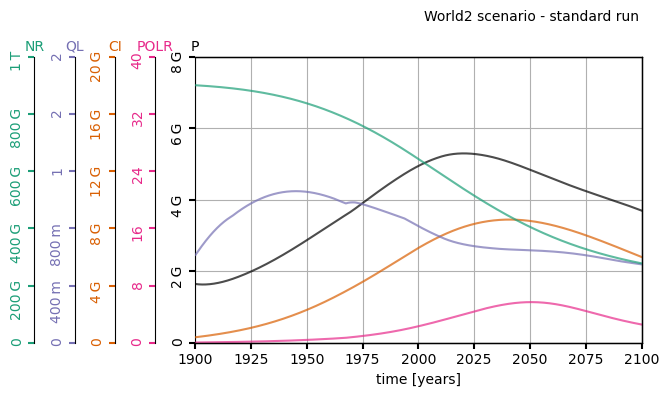

In [2]:
from pyworld2.utils import plot_world_variables

# Plot all 5 key variables in one figure (same style as hello_world2)
plot_world_variables(w2.time,
                     [w2.p, w2.polr, w2.ci, w2.ql, w2.nr],
                     ["P", "POLR", "CI", "QL", "NR"],
                     [[0, 8e9], [0, 40], [0, 20e9], [0, 2], [0, 1000e9]],
                     figsize=(7, 4), grid=True,
                     title="World2 scenario - standard run")

# Make lines thinner
for ax in plt.gcf().get_axes():
    for line in ax.get_lines():
        line.set_linewidth(1.5)

plt.show()

## Step 3: Summary Statistics for Baseline

In [3]:
peak_pop_idx = np.argmax(w2.p)
peak_pol_idx = np.argmax(w2.pol)
peak_ci_idx = np.argmax(w2.ci)
peak_ql_idx = np.argmax(w2.ql[1:]) + 1  # skip NaN at index 0

print('=== World2 Standard Run - Summary Statistics ===')
print(f'\nPopulation:')
print(f'  Peak: {w2.p[peak_pop_idx]:.2e} in year {w2.time[peak_pop_idx]:.0f}')
print(f'  Final (2100): {w2.p[-1]:.2e}')

print(f'\nNatural Resources:')
print(f'  Initial: {w2.nr[0]:.2e}')
print(f'  Final (2100): {w2.nr[-1]:.2e}')
print(f'  Fraction remaining: {w2.nr[-1]/w2.nr[0]:.2%}')

print(f'\nCapital Investment:')
print(f'  Peak: {w2.ci[peak_ci_idx]:.2e} in year {w2.time[peak_ci_idx]:.0f}')
print(f'  Final (2100): {w2.ci[-1]:.2e}')

print(f'\nPollution:')
print(f'  Peak: {w2.pol[peak_pol_idx]:.2e} in year {w2.time[peak_pol_idx]:.0f}')
print(f'  Final (2100): {w2.pol[-1]:.2e}')

print(f'\nQuality of Life:')
print(f'  Peak: {w2.ql[peak_ql_idx]:.4f} in year {w2.time[peak_ql_idx]:.0f}')
print(f'  Final (2100): {w2.ql[-1]:.4f}')

=== World2 Standard Run - Summary Statistics ===

Population:
  Peak: 5.30e+09 in year 2020
  Final (2100): 3.70e+09

Natural Resources:
  Initial: 9.00e+11
  Final (2100): 2.78e+11
  Fraction remaining: 30.92%

Capital Investment:
  Peak: 8.62e+09 in year 2041
  Final (2100): 6.01e+09

Pollution:
  Peak: 2.06e+10 in year 2051
  Final (2100): 9.31e+09

Quality of Life:
  Peak: 1.0604 in year 1945
  Final (2100): 0.5494


## Step 4: Parameter Sensitivity — Varying Key Parameters Individually

We vary each of the four required parameters after 1970, holding all others at default.
- **BRN** (Birth Rate Normal): default 0.04
- **DRN** (Death Rate Normal): default 0.028
- **CIGN** (Capital Investment Generation Normal): default 0.05
- **POLN** (Pollution Normal): default 1.0

In [4]:
# Helper: create a custom switch JSON file with one parameter changed after 1970
def make_switch_json(param_name, new_value, filepath='temp_switch.json'):
    """
    Creates a switch JSON where `param_name` is changed to `new_value` after 1970.
    All other parameters stay at their defaults.
    """
    defaults = {
        'BRN':  {'val': 0.04,  'trigger': 'SWT1'},
        'NRUN': {'val': 1.0,   'trigger': 'SWT2'},
        'DRN':  {'val': 0.028, 'trigger': 'SWT3'},
        'FC':   {'val': 1.0,   'trigger': 'SWT7'},
        'CIGN': {'val': 0.05,  'trigger': 'SWT4'},
        'CIDN': {'val': 0.025, 'trigger': 'SWT5'},
        'POLN': {'val': 1.0,   'trigger': 'SWT6'},
    }
    
    switch_list = []
    for name, info in defaults.items():
        entry = {
            name: info['val'],
            f"{name}1": new_value if name == param_name else info['val'],
            "trigger.name": info['trigger'],
            "trigger.value": 1970
        }
        switch_list.append(entry)
    
    with open(filepath, 'w') as f:
        json.dump(switch_list, f, indent=1)
    return filepath


def run_with_switch(param_name, new_value):
    """Run a World2 simulation with one switch parameter changed."""
    filepath = make_switch_json(param_name, new_value)
    model = World2()
    model.set_state_variables()
    model.set_initial_state()
    model.set_table_functions()
    model.set_switch_functions(filepath)
    model.run()
    return model

print('Helper functions defined.')

Helper functions defined.


### 4a: Varying Birth Rate Normal (BRN)

Default BRN = 0.04. We test lower (0.02, 0.03) and higher (0.05, 0.06) values after 1970.

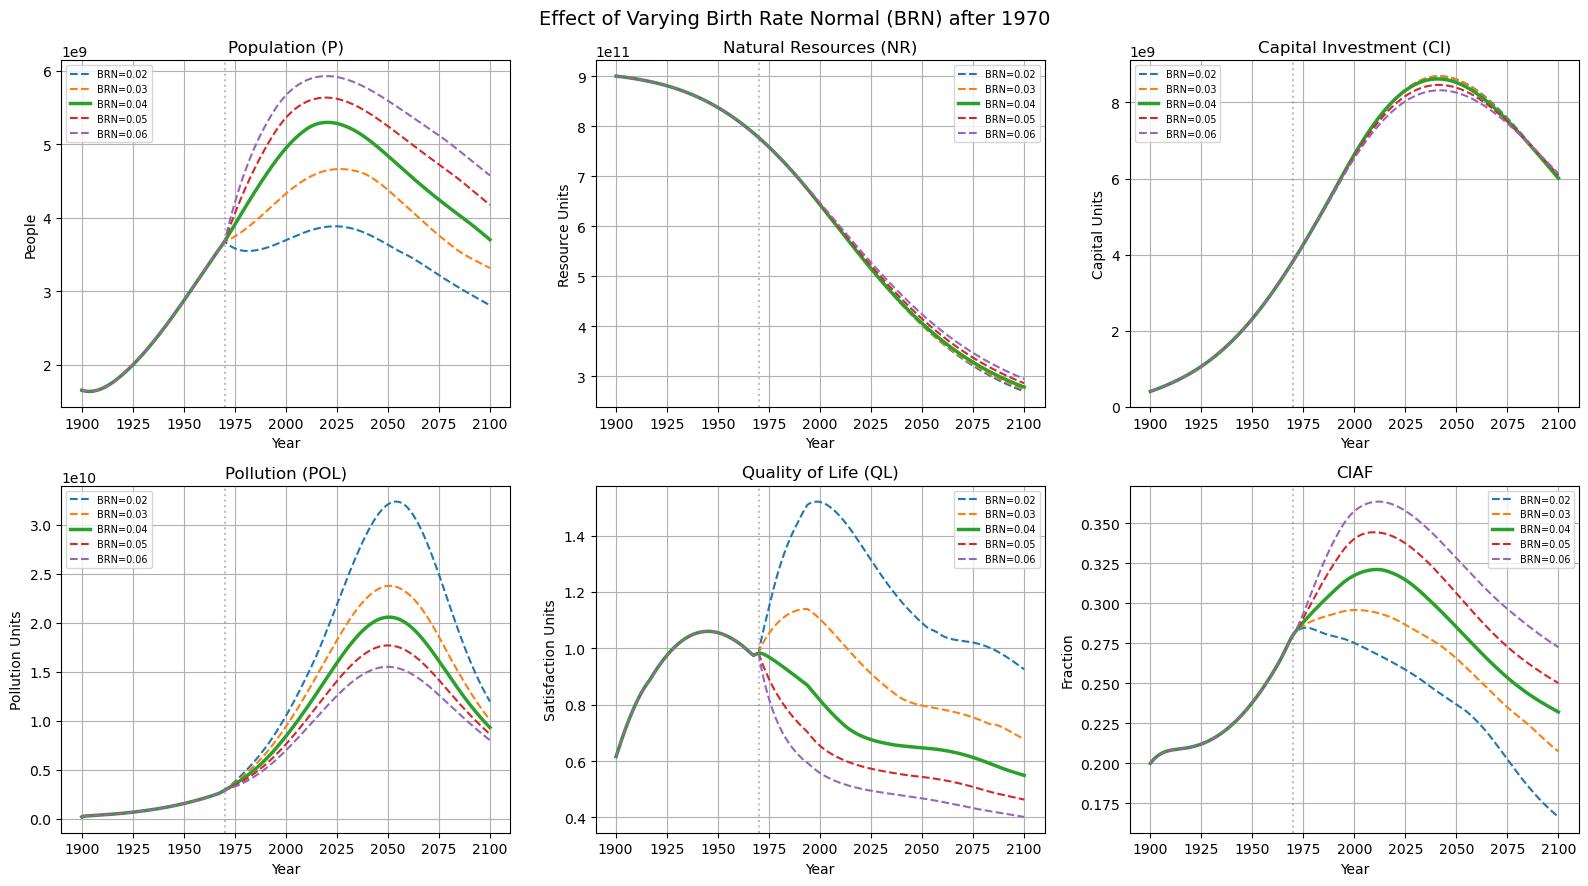

In [5]:
brn_values = [0.02, 0.03, 0.04, 0.05, 0.06]
brn_models = {v: run_with_switch('BRN', v) for v in brn_values}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Effect of Varying Birth Rate Normal (BRN) after 1970', fontsize=14)

plot_vars = [
    ('p',    'Population (P)',         'People'),
    ('nr',   'Natural Resources (NR)', 'Resource Units'),
    ('ci',   'Capital Investment (CI)','Capital Units'),
    ('pol',  'Pollution (POL)',        'Pollution Units'),
    ('ql',   'Quality of Life (QL)',   'Satisfaction Units'),
    ('ciaf', 'CIAF',                   'Fraction'),
]

for idx, (attr, title, ylabel) in enumerate(plot_vars):
    ax = axes[idx // 3, idx % 3]
    for v in brn_values:
        m = brn_models[v]
        lw = 2.5 if v == 0.04 else 1.5
        ls = '-' if v == 0.04 else '--'
        ax.plot(m.time, getattr(m, attr), linewidth=lw, linestyle=ls, label=f'BRN={v}')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)
    ax.grid(True)
    ax.axvline(x=1970, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### 4b: Varying Death Rate Normal (DRN)

Default DRN = 0.028. We test lower (0.014, 0.021) and higher (0.035, 0.042) values after 1970.

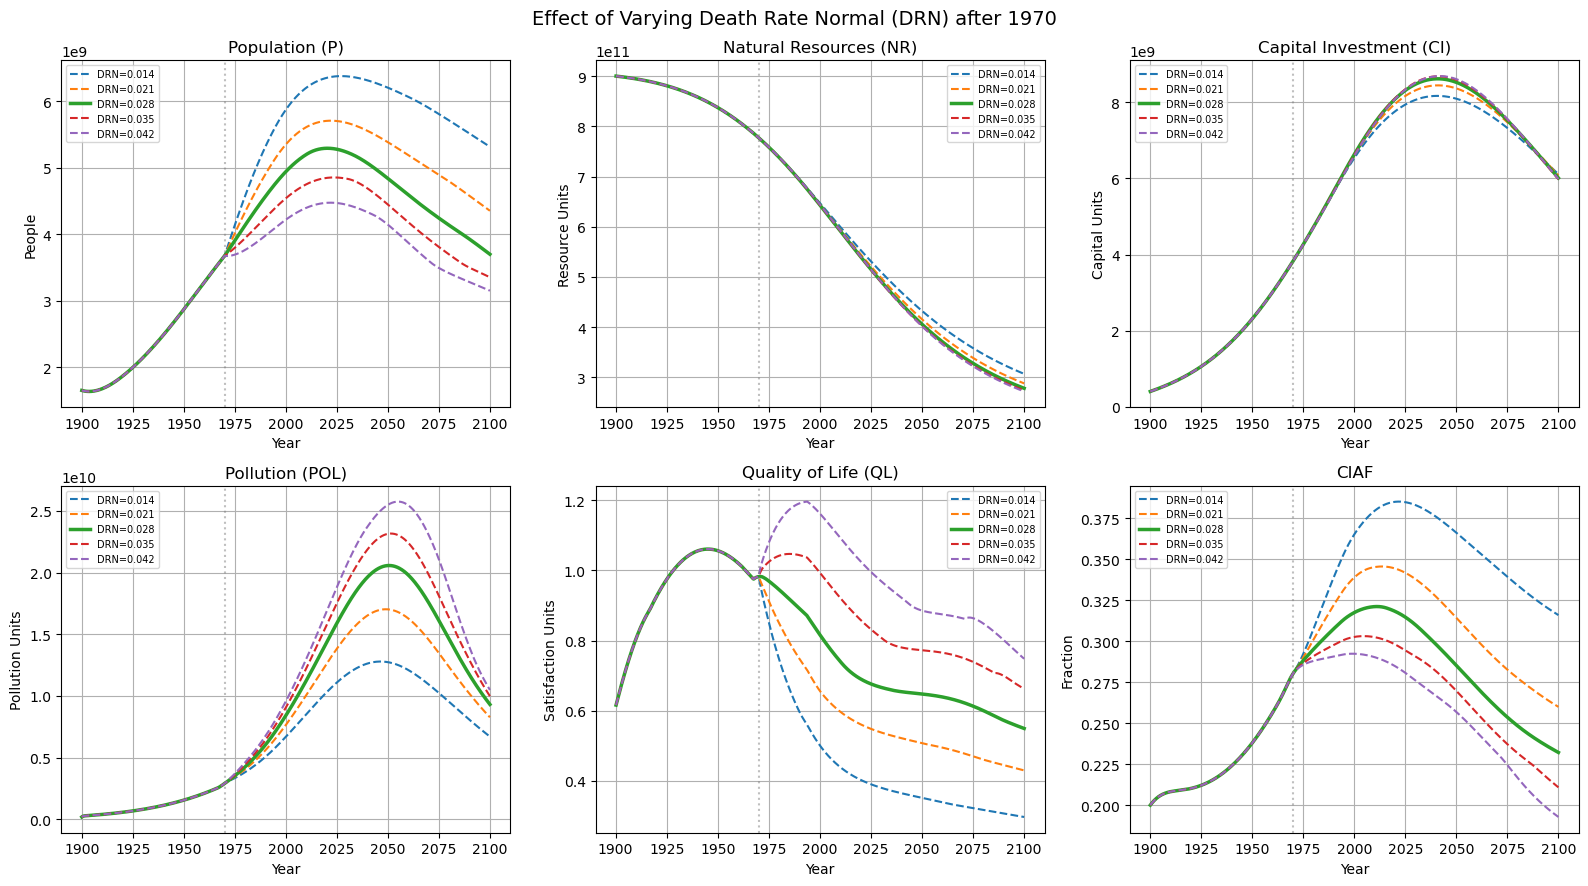

In [6]:
drn_values = [0.014, 0.021, 0.028, 0.035, 0.042]
drn_models = {v: run_with_switch('DRN', v) for v in drn_values}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Effect of Varying Death Rate Normal (DRN) after 1970', fontsize=14)

for idx, (attr, title, ylabel) in enumerate(plot_vars):
    ax = axes[idx // 3, idx % 3]
    for v in drn_values:
        m = drn_models[v]
        lw = 2.5 if v == 0.028 else 1.5
        ls = '-' if v == 0.028 else '--'
        ax.plot(m.time, getattr(m, attr), linewidth=lw, linestyle=ls, label=f'DRN={v}')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)
    ax.grid(True)
    ax.axvline(x=1970, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### 4c: Varying Capital Investment Generation Normal (CIGN)

Default CIGN = 0.05. We test lower (0.02, 0.035) and higher (0.065, 0.08) values after 1970.

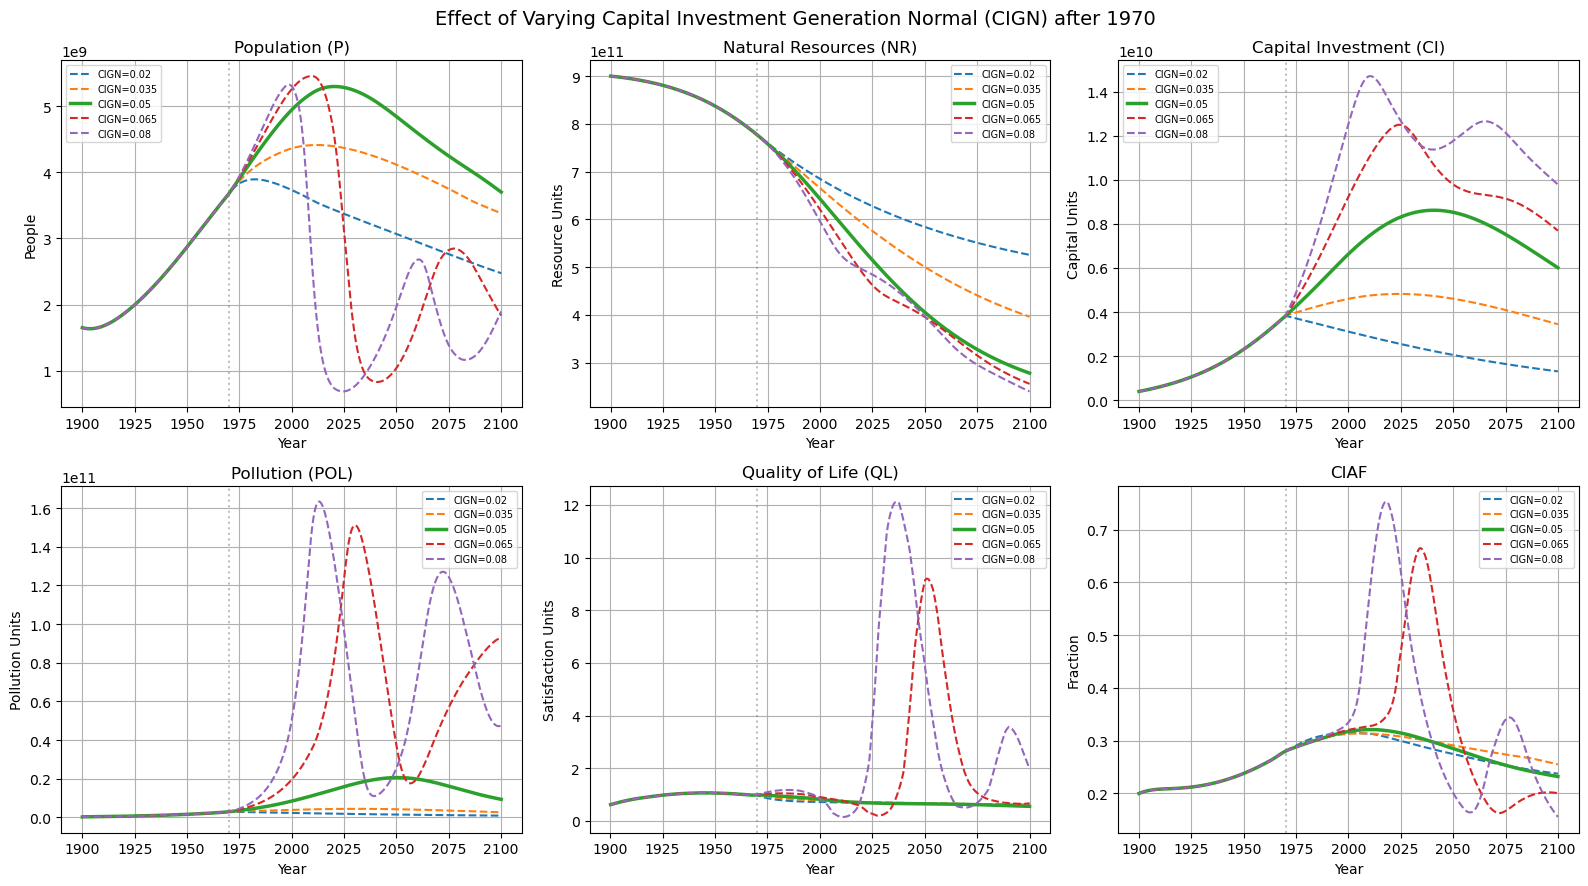

In [7]:
cign_values = [0.02, 0.035, 0.05, 0.065, 0.08]
cign_models = {v: run_with_switch('CIGN', v) for v in cign_values}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Effect of Varying Capital Investment Generation Normal (CIGN) after 1970', fontsize=14)

for idx, (attr, title, ylabel) in enumerate(plot_vars):
    ax = axes[idx // 3, idx % 3]
    for v in cign_values:
        m = cign_models[v]
        lw = 2.5 if v == 0.05 else 1.5
        ls = '-' if v == 0.05 else '--'
        ax.plot(m.time, getattr(m, attr), linewidth=lw, linestyle=ls, label=f'CIGN={v}')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)
    ax.grid(True)
    ax.axvline(x=1970, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### 4d: Varying Pollution Normal (POLN)

Default POLN = 1.0. We test lower (0.25, 0.5) and higher (1.5, 2.0) values after 1970.

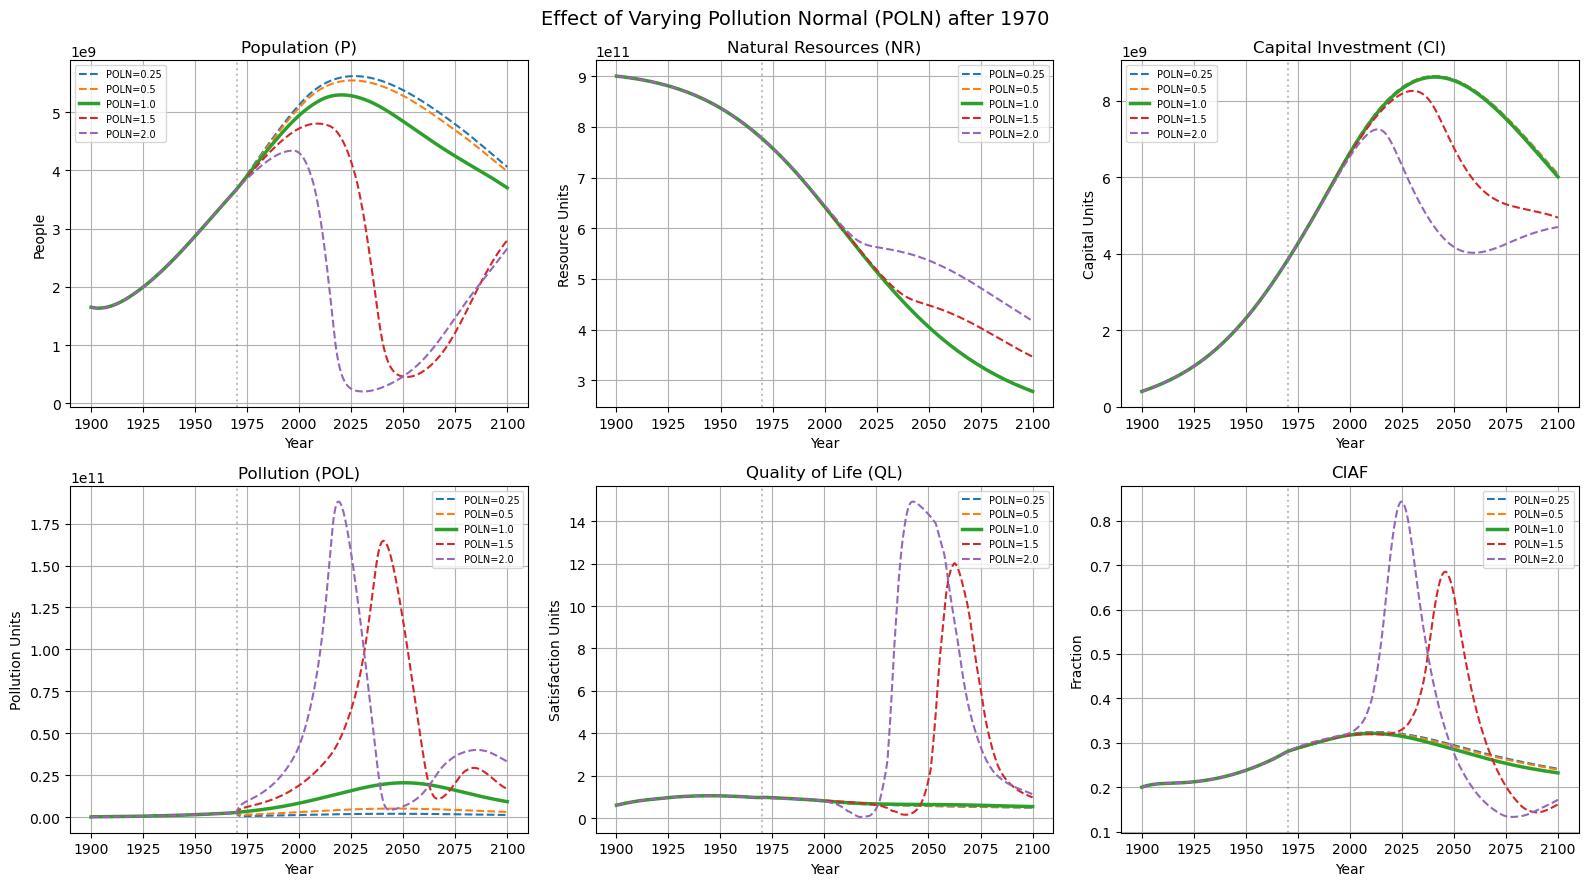

In [8]:
poln_values = [0.25, 0.5, 1.0, 1.5, 2.0]
poln_models = {v: run_with_switch('POLN', v) for v in poln_values}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Effect of Varying Pollution Normal (POLN) after 1970', fontsize=14)

for idx, (attr, title, ylabel) in enumerate(plot_vars):
    ax = axes[idx // 3, idx % 3]
    for v in poln_values:
        m = poln_models[v]
        lw = 2.5 if v == 1.0 else 1.5
        ls = '-' if v == 1.0 else '--'
        ax.plot(m.time, getattr(m, attr), linewidth=lw, linestyle=ls, label=f'POLN={v}')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)
    ax.grid(True)
    ax.axvline(x=1970, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### 4e: Summary Table — Peak Population & Final Quality of Life Across All Variations

In [9]:
# Summary table for all parameter sweeps
print(f'{"Parameter":<10} {"Value":<10} {"Peak Pop":>12} {"Peak Pop Year":>14} {"Final QL":>10} {"Peak Pollution":>15} {"NR Remaining%":>14}')
print('-' * 85)

all_sweeps = [
    ('BRN',  brn_values,  brn_models),
    ('DRN',  drn_values,  drn_models),
    ('CIGN', cign_values, cign_models),
    ('POLN', poln_values, poln_models),
]

for param_name, values, models in all_sweeps:
    for v in values:
        m = models[v]
        peak_idx = np.argmax(m.p)
        peak_pol_idx = np.argmax(m.pol)
        nr_pct = m.nr[-1] / m.nr[0] * 100
        print(f'{param_name:<10} {v:<10.3f} {m.p[peak_idx]:>12.2e} {m.time[peak_idx]:>14.0f} {m.ql[-1]:>10.4f} {m.pol[peak_pol_idx]:>15.2e} {nr_pct:>13.1f}%')
    print()

Parameter  Value          Peak Pop  Peak Pop Year   Final QL  Peak Pollution  NR Remaining%
-------------------------------------------------------------------------------------
BRN        0.020          3.88e+09           2024     0.9256        3.23e+10          29.9%
BRN        0.030          4.66e+09           2026     0.6782        2.38e+10          30.4%
BRN        0.040          5.30e+09           2020     0.5494        2.06e+10          30.9%
BRN        0.050          5.63e+09           2020     0.4636        1.77e+10          31.8%
BRN        0.060          5.93e+09           2020     0.4019        1.55e+10          32.7%

DRN        0.014          6.38e+09           2027     0.2975        1.28e+10          34.1%
DRN        0.021          5.71e+09           2022     0.4300        1.70e+10          32.0%
DRN        0.028          5.30e+09           2020     0.5494        2.06e+10          30.9%
DRN        0.035          4.86e+09           2024     0.6621        2.32e+10         

## Step 5: Deeper Exploration — Additional Parameters & Combined Policies

Beyond the four required parameters, we explore:
- **NRUN** (Natural Resource Usage Normal) — already seen in scenario 2, now with finer sweep
- **FC** (Food Coefficient)
- **CIDN** (Capital Investment Discard Normal)
- **Combined policies** — changing multiple parameters simultaneously

### 5a: Varying Natural Resource Usage Normal (NRUN)

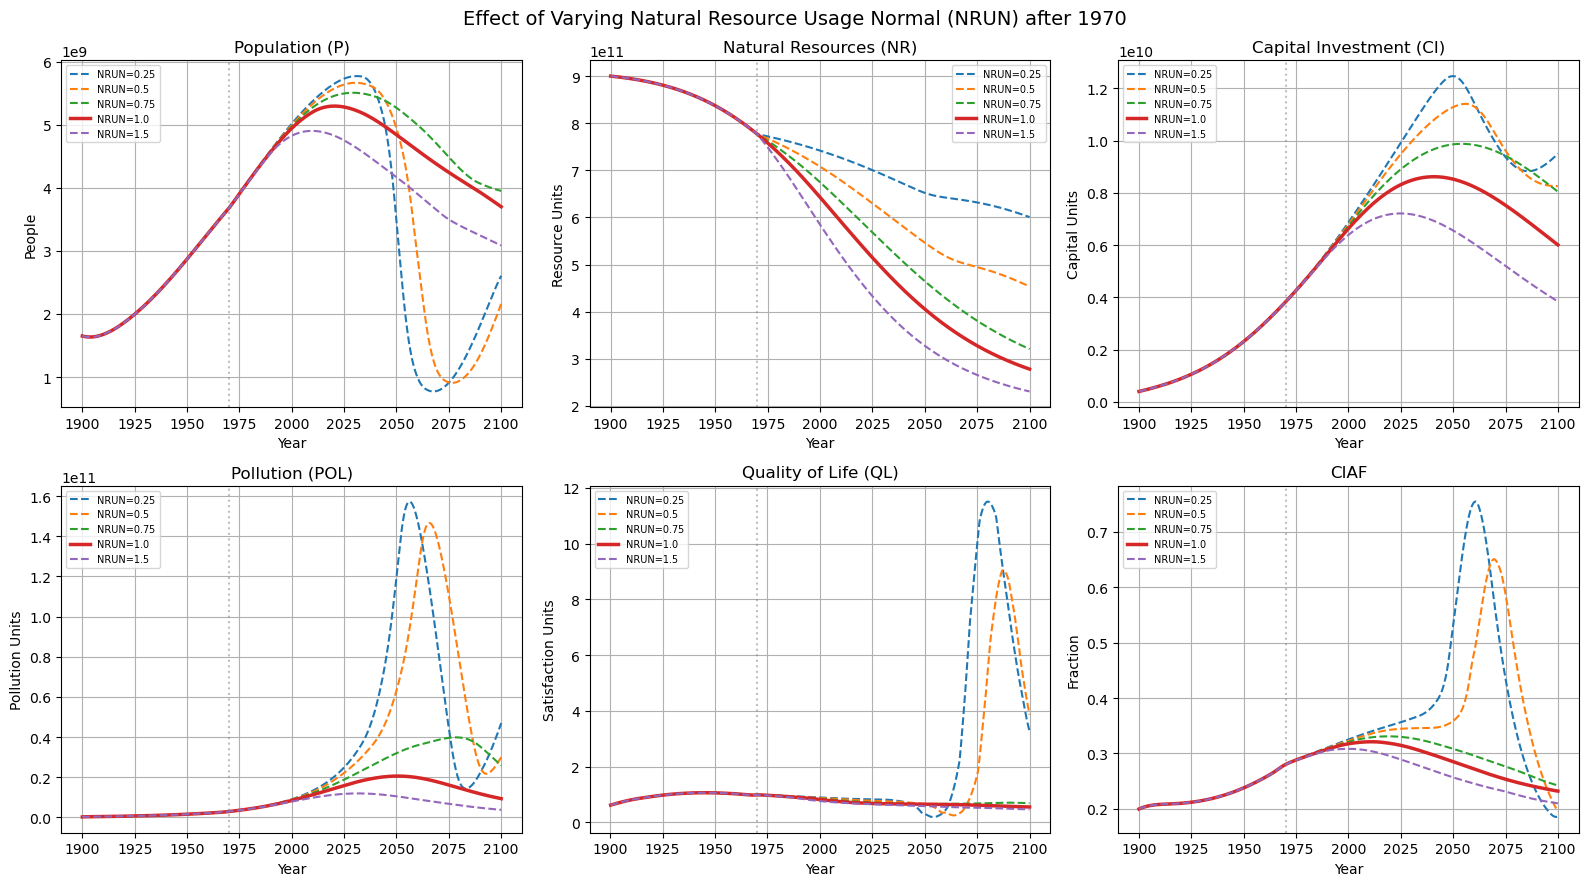

In [10]:
nrun_values = [0.25, 0.5, 0.75, 1.0, 1.5]
nrun_models = {v: run_with_switch('NRUN', v) for v in nrun_values}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Effect of Varying Natural Resource Usage Normal (NRUN) after 1970', fontsize=14)

for idx, (attr, title, ylabel) in enumerate(plot_vars):
    ax = axes[idx // 3, idx % 3]
    for v in nrun_values:
        m = nrun_models[v]
        lw = 2.5 if v == 1.0 else 1.5
        ls = '-' if v == 1.0 else '--'
        ax.plot(m.time, getattr(m, attr), linewidth=lw, linestyle=ls, label=f'NRUN={v}')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)
    ax.grid(True)
    ax.axvline(x=1970, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### 5b: Varying Food Coefficient (FC) and Capital Investment Discard Normal (CIDN)

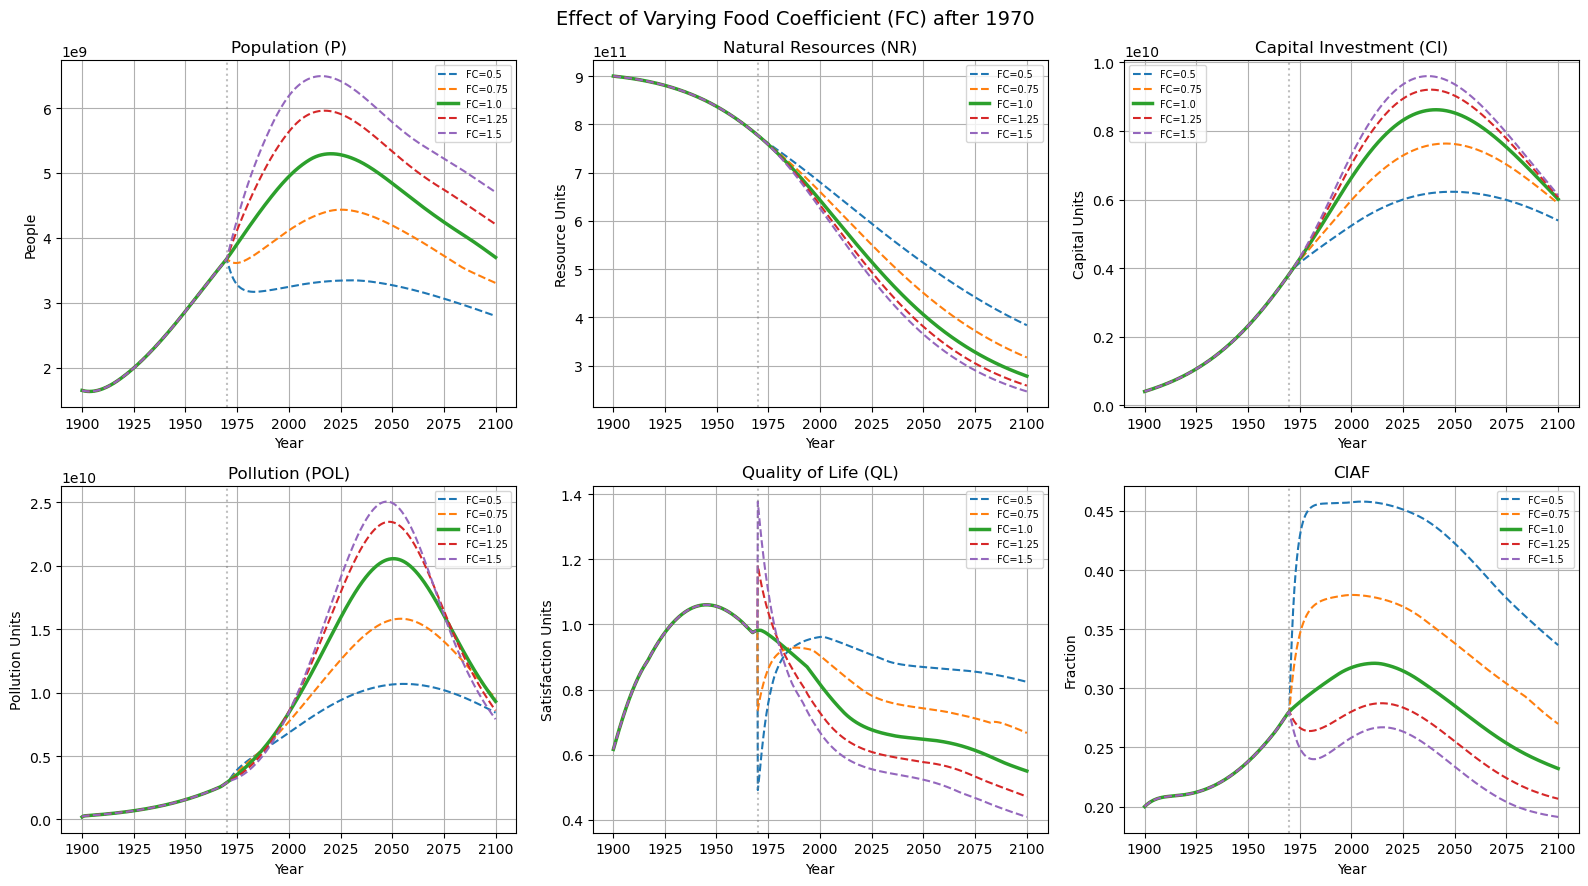

In [11]:
# Food Coefficient (FC)
fc_values = [0.5, 0.75, 1.0, 1.25, 1.5]
fc_models = {v: run_with_switch('FC', v) for v in fc_values}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Effect of Varying Food Coefficient (FC) after 1970', fontsize=14)

for idx, (attr, title, ylabel) in enumerate(plot_vars):
    ax = axes[idx // 3, idx % 3]
    for v in fc_values:
        m = fc_models[v]
        lw = 2.5 if v == 1.0 else 1.5
        ls = '-' if v == 1.0 else '--'
        ax.plot(m.time, getattr(m, attr), linewidth=lw, linestyle=ls, label=f'FC={v}')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)
    ax.grid(True)
    ax.axvline(x=1970, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

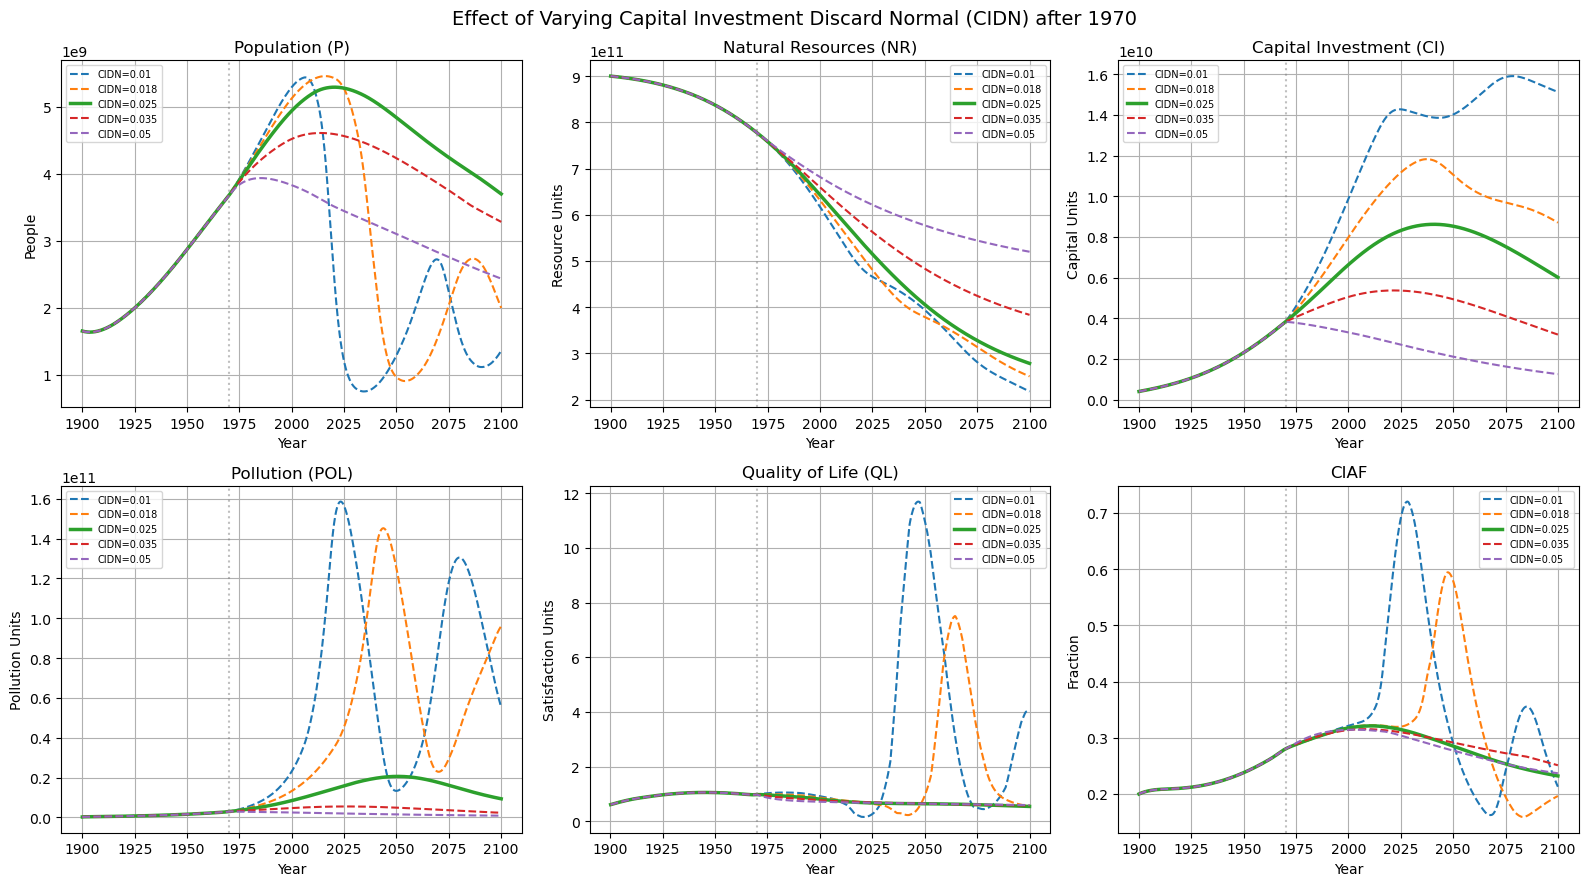

In [12]:
# Capital Investment Discard Normal (CIDN)
cidn_values = [0.01, 0.018, 0.025, 0.035, 0.05]
cidn_models = {v: run_with_switch('CIDN', v) for v in cidn_values}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Effect of Varying Capital Investment Discard Normal (CIDN) after 1970', fontsize=14)

for idx, (attr, title, ylabel) in enumerate(plot_vars):
    ax = axes[idx // 3, idx % 3]
    for v in cidn_values:
        m = cidn_models[v]
        lw = 2.5 if v == 0.025 else 1.5
        ls = '-' if v == 0.025 else '--'
        ax.plot(m.time, getattr(m, attr), linewidth=lw, linestyle=ls, label=f'CIDN={v}')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)
    ax.grid(True)
    ax.axvline(x=1970, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### 5c: Combined Policies — Changing Multiple Parameters Simultaneously

We test several multi-parameter "policy packages" applied after 1970 to see if coordinated interventions can avoid the single-fix trap.

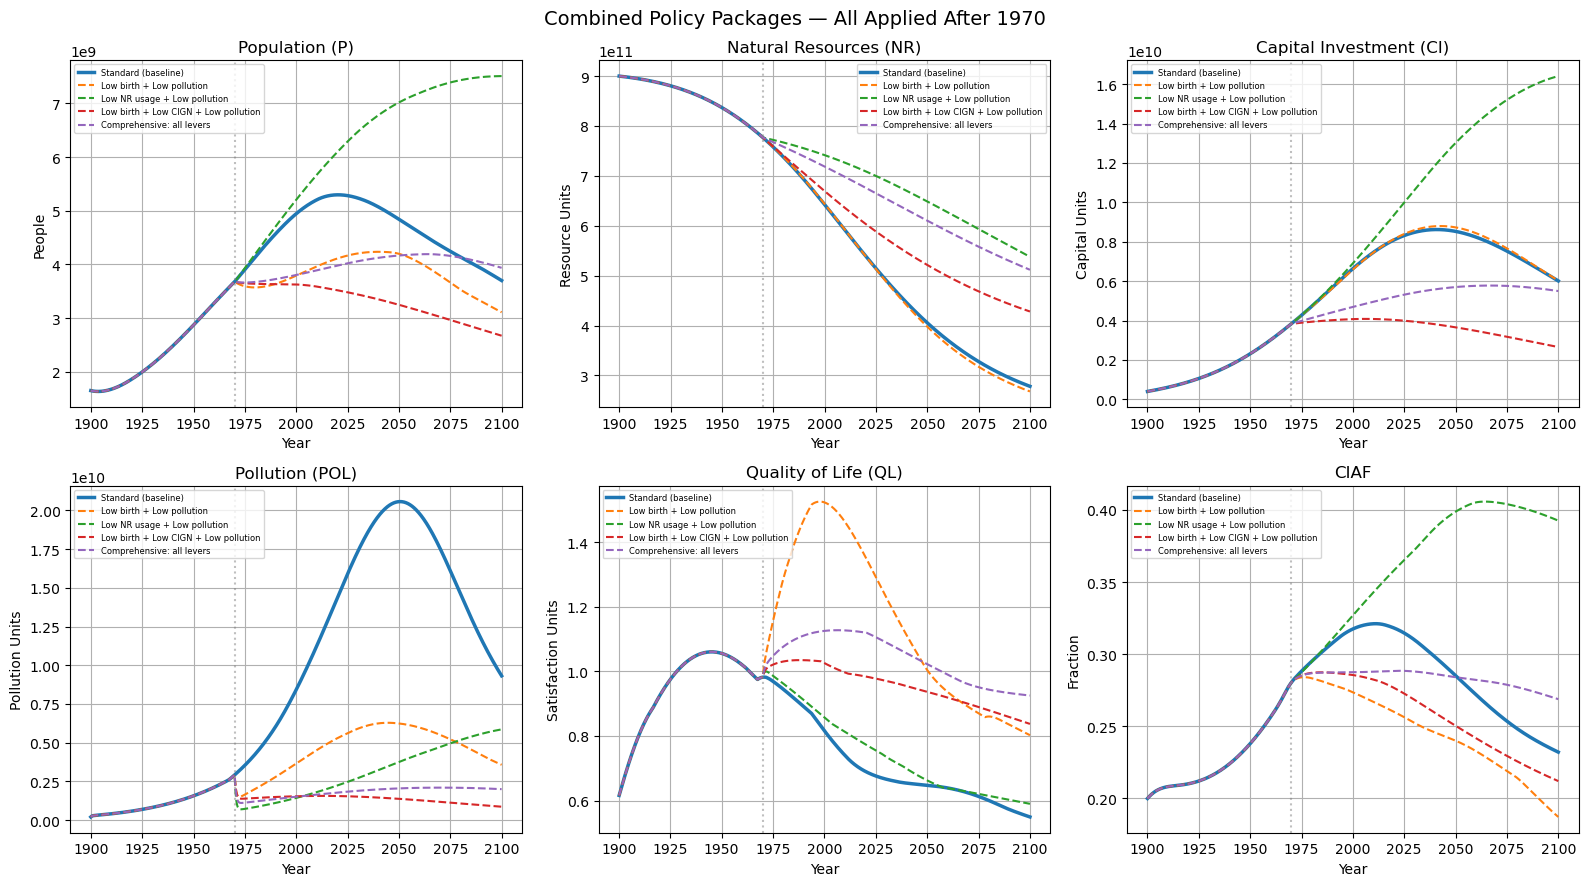

In [13]:
# Helper for multi-parameter switch JSON
def make_multi_switch_json(param_changes, filepath='temp_multi_switch.json'):
    """
    param_changes: dict like {'BRN': 0.02, 'POLN': 0.5}
    All unlisted parameters stay at defaults.
    """
    defaults = {
        'BRN':  {'val': 0.04,  'trigger': 'SWT1'},
        'NRUN': {'val': 1.0,   'trigger': 'SWT2'},
        'DRN':  {'val': 0.028, 'trigger': 'SWT3'},
        'FC':   {'val': 1.0,   'trigger': 'SWT7'},
        'CIGN': {'val': 0.05,  'trigger': 'SWT4'},
        'CIDN': {'val': 0.025, 'trigger': 'SWT5'},
        'POLN': {'val': 1.0,   'trigger': 'SWT6'},
    }
    switch_list = []
    for name, info in defaults.items():
        entry = {
            name: info['val'],
            f"{name}1": param_changes.get(name, info['val']),
            "trigger.name": info['trigger'],
            "trigger.value": 1970
        }
        switch_list.append(entry)
    with open(filepath, 'w') as f:
        json.dump(switch_list, f, indent=1)
    return filepath

def run_multi_switch(param_changes):
    filepath = make_multi_switch_json(param_changes)
    model = World2()
    model.set_state_variables()
    model.set_initial_state()
    model.set_table_functions()
    model.set_switch_functions(filepath)
    model.run()
    return model

# Define combined policy packages
policies = {
    'Standard (baseline)': {},
    'Low birth + Low pollution': {'BRN': 0.02, 'POLN': 0.5},
    'Low NR usage + Low pollution': {'NRUN': 0.25, 'POLN': 0.25},
    'Low birth + Low CIGN + Low pollution': {'BRN': 0.025, 'CIGN': 0.03, 'POLN': 0.5},
    'Comprehensive: all levers': {'BRN': 0.025, 'NRUN': 0.5, 'CIGN': 0.035, 'POLN': 0.4},
}

policy_models = {name: run_multi_switch(changes) for name, changes in policies.items()}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Combined Policy Packages — All Applied After 1970', fontsize=14)

for idx, (attr, title, ylabel) in enumerate(plot_vars):
    ax = axes[idx // 3, idx % 3]
    for name, m in policy_models.items():
        lw = 2.5 if name == 'Standard (baseline)' else 1.5
        ls = '-' if name == 'Standard (baseline)' else '--'
        ax.plot(m.time, getattr(m, attr), linewidth=lw, linestyle=ls, label=name)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.legend(fontsize=6)
    ax.grid(True)
    ax.axvline(x=1970, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:
# Summary table for combined policies
print(f'{"Policy":<40} {"Peak Pop":>12} {"Year":>6} {"Final QL":>10} {"Peak Pol":>12} {"NR Rem%":>8}')
print('-' * 95)

for name, m in policy_models.items():
    peak_idx = np.argmax(m.p)
    peak_pol_idx = np.argmax(m.pol)
    nr_pct = m.nr[-1] / m.nr[0] * 100
    print(f'{name:<40} {m.p[peak_idx]:>12.2e} {m.time[peak_idx]:>6.0f} {m.ql[-1]:>10.4f} {m.pol[peak_pol_idx]:>12.2e} {nr_pct:>7.1f}%')

Policy                                       Peak Pop   Year   Final QL     Peak Pol  NR Rem%
-----------------------------------------------------------------------------------------------
Standard (baseline)                          5.30e+09   2020     0.5494     2.06e+10    30.9%
Low birth + Low pollution                    4.23e+09   2040     0.8025     6.28e+09    29.8%
Low NR usage + Low pollution                 7.51e+09   2100     0.5901     5.86e+09    59.8%
Low birth + Low CIGN + Low pollution         3.68e+09   1970     0.8374     2.91e+09    47.6%
Comprehensive: all levers                    4.19e+09   2064     0.9252     2.91e+09    56.9%


## Step 6: Discussion & Conclusions for Part 1

### Key Feedback Loops Identified

The World2 model contains several interconnected feedback loops. The most important ones are:

**1. Population–Capital–Pollution Reinforcing Loop (R1)**
- More people → more capital investment generation (CIG) → higher CI → higher capital-investment ratio (CIR) → more pollution generation (POLCM) → higher pollution → increased death rate (DRPM) & reduced food (FPM) → fewer people
- This is ultimately a *balancing* loop with a delay — population growth drives industrialization, which creates pollution that eventually suppresses population.

**2. Population–Natural Resources Balancing Loop (B1)**
- More people → higher natural resource usage (NRUR) → lower NR → lower NRFR → lower natural resource extraction multiplier (NREM) → lower effective capital investment ratio (ECIR) → lower material standard of living (MSL) → lower birth rate multiplier (BRMM) → fewer births → fewer people
- Resource depletion acts as a brake on economic growth and population.

**3. Capital–Agriculture–Food Balancing Loop (B2)**
- Higher CIR → higher MSL → shifts CIAF via quality-of-life ratio → changes food production (FPCI) → affects food ratio (FR) → influences birth/death rates → population changes → CIR changes
- This loop governs the trade-off between industrial and agricultural investment.

**4. Pollution–Food–Population Loop (B3)**
- Higher pollution → lower food-from-pollution multiplier (FPM) → lower food ratio → higher death rate (DRFM) and lower birth rate (BRFM) → population decline → less pollution generation
- Pollution indirectly limits population through food supply degradation.

### Parameter Sensitivity Insights

From the individual parameter sweeps:

- **BRN (Birth Rate):** Highly sensitive. Reducing BRN after 1970 significantly lowers peak population and delays resource depletion. However, very low BRN can lead to population decline below replacement.
- **POLN (Pollution Normal):** Very impactful. Reducing pollution production substantially improves quality of life and delays population collapse. This is one of the most effective single interventions.
- **CIGN (Capital Investment):** Moderate effect. Lower CIGN slows industrialization, reducing pollution but also reducing material standard of living. There is a trade-off between economic growth and environmental impact.
- **DRN (Death Rate):** Counterintuitive effects. Lower death rates increase population, which accelerates resource depletion and pollution — potentially worsening long-term outcomes.
- **NRUN (Natural Resource Usage):** As seen in Scenario 2, reducing NR usage alone shifts the mode of collapse from resource depletion to pollution crisis. Must be paired with pollution control.
- **FC (Food Coefficient):** Higher food availability supports larger populations, but this intensifies pressure on resources and pollution.
- **CIDN (Capital Investment Discard):** Lower discard rates mean capital persists longer, amplifying both productive capacity and pollution.

### Combined Policies vs. Single-Parameter Changes

The most important finding is that **single-parameter interventions are insufficient** and can be counterproductive. The system's interconnected feedback loops transfer pressure from one subsystem to another. Effective policies must address multiple leverage points simultaneously:
- Reducing both birth rate AND pollution is more effective than either alone
- Pairing resource conservation with pollution control avoids the Scenario 2 trap
- The "comprehensive" policy (moderate adjustments to BRN, NRUN, CIGN, POLN) performs best overall

### Model Strengths
- Captures the essential dynamics of population-resource-pollution interactions
- Demonstrates counterintuitive behavior and the dangers of narrow interventions
- Simple enough to understand feedback structures while still producing complex emergent behavior
- Useful for exploring "what-if" scenarios and building systems thinking intuition

### Model Weaknesses
- Highly aggregated — treats the entire world as a single homogeneous system (no regional variation)
- Fixed functional relationships (table functions) may not reflect real-world nonlinearities accurately
- No technological change or innovation dynamics — technology is implicitly fixed
- Parameter values from the 1970s may not reflect current conditions
- No explicit modeling of energy systems, climate, or governance
- Assumes smooth continuous change — does not capture shocks, wars, or discontinuities
- The model's conclusions are sensitive to table function shapes that are difficult to validate empirically

### Looking Ahead
These insights will inform Part 2 (automated policy design), where we will systematically search the parameter space of the more detailed World3 model to find policies that achieve sustainable development.